## M91 FastHall<sup>TM</sup> QCoDeS driver example

The M91 has the ability to execute the following measurement functions: contact check, resistivity, FastHall<sup>TM</sup>, DC Hall and four wire.

The features available depend on what sample type you have. The sample type can be van der Pauw or Hall bar (see M91 FastHall<sup>TM</sup> manual from LakeShore for more information). FastHall<sup>TM</sup> can only be done on a van der Pauw sample. Auto optimised (link) measurements are available for the contact check, resistivity and FastHall<sup>TM</sup> measurements in the case of a van der Pauw sample only.

The driver is structured such that each of these measurement functions is an `InstrumentModule` added to the M91 instrument. Changing the sample type parameter (e.g. `M91.sample_type("Hall_bar")`) changes the submodules associated with the M91. If the sample type is Hall bar then the FastHall<sup>TM</sup> instrument module will no longer exist and the auto optimise functionality is removed from the relevant measurements.

Instrument Modules:
- `M91.ContactCheck`
- `M91.Resistivity`
- `M91.FastHall`
- `M91.DCHall`
- `M91.FourWire`

Each instrument module will have a number of parameters associated with it. These parameters are the settings configurable for that given measurement. Changing e.g. the auto_optimise parameter will add or remove parameters from the module in accordance with the required settings needed to run the measurement.

Each module has a `start` function which will start that measurement. The start function will also return the measurement results as a SimpleNamespace. To show the results when the function is run use set `show_results=True`. In the case of the contact check, the results will be plotted and displayed rather than returned (you can still get the results using the function described below).

Each module also has the following functions:
1. `reset` - resets the measurement to a not run state, cancelling any running measurement and overwritting the previously run measurement's results
3. `get_results` - returns the summary results from the last run measurement as a SimpleNamespace
4. `get_all_results` - returns all results from the last run measurement (i.e individual samples) as a SimpleNamespace
5. `get_running_status` - returns True/False to indicate if that measurement is currently running. Used within the start functions to determine when to return the results.

Looking at the snapshot of the whole M91 will show you the current settings for all measurements as well as the sample type and timeout parameters of the instrument. It may be more useful to look at the snapshot for just the measurement type of interest i.e. `M91.Resistivity.print_readable_snapshot(update=True)`.

None of the parameters are associated with any physical setting on the instrument. They are essentially placeholders for the settings you need for each kind of measurement. Setting `M91.Resistivity.blanking_time(0.003)` does not send any command to the M91, it just changes the parameter value. When the `M91.Resisitivity.start()` function is subsequently called the command string written to the instrument will be populated by the parameter values.

Most parameters have a docstring to explain what they are. This can be accessed by using shift+tab on the parameter of interest or using `help`.

E.g. `help(M91.ContactCheck.blanking_time)`

> Help on BoundedValueParameter in module M91_FastHall:
>
>the time to wait for the hardware to settle before gathering readings<br>
>Parameter class:
>* `name` blanking_time
>* `label` blanking_time
>* `unit` s
>* `vals` Numbers

In [1]:
import sys
import time
import logging as log
import numpy as np

import qcodes as qc
from qcodes.logger.logger import start_all_logging
from qcodes.dataset import load_or_create_experiment, plot_dataset
from qcodes.dataset.measurements import Measurement
from qcodes.instrument.parameter import Parameter

from qcodes_contrib_drivers.drivers.Lakeshore.M91_FastHall import M91_FastHall

start_all_logging()
log = log.getLogger()

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : /home/jupyter-abi_g/.qcodes/logs/command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : /home/jupyter-abi_g/.qcodes/logs/260413-1352159-qcodes.log


## Connect to M91

In [2]:
try:
    M91 = M91_FastHall('M91','TCPIP::192.168.2.24::7777::SOCKET')
    M91.timeout(1)
except Exception as err:
    log.critical(err)
    print(f'Connection failed: {err}')

exp = load_or_create_experiment(experiment_name='M91 example')

Connected to: Lake Shore M91 (serial:LSA2P79, firmware:2.0.2023121202) in 0.30s


## Snapshot

In [3]:
M91.print_readable_snapshot(update=True)

M91:
	parameter  value
--------------------------------------------------------------------------------
IDN         :	{'vendor': 'Lake Shore', 'model': 'M91', 'serial': 'LSA2GLN', '...
keypad_lock :	True 
sample_type :	van_der_Pauw 
timeout     :	1 (s)
M91_Resistivity:
	parameter       value
--------------------------------------------------------------------------------
auto_optimise    :	True 
maximum_samples  :	100 
measure_range    :	AUTO (A or V)
minimum_SNR      :	30 
sample_thickness :	DEF (m)
M91_DCHall:
	parameter                       value
--------------------------------------------------------------------------------
blanking_time                    :	0.002 (s)
compliance_voltage               :	10 (V)
excitation_current_range         :	AUTO (A)
excitation_current_value         :	None (A)
excitation_measure_current_range :	AUTO (A)
excitation_type                  :	CURR 
field_reversal                   :	ON 
maximum_samples                  :	100 
measure_voltage_range  

In [4]:
# changing to Hall bar will remove the FastHall module
M91.sample_type("Hall_bar")
M91.print_readable_snapshot()

M91:
	parameter  value
--------------------------------------------------------------------------------
IDN         :	{'vendor': 'Lake Shore', 'model': 'M91', 'serial': 'LSA2GLN', '...
sample_type :	Hall_bar 
timeout     :	1 (s)
M91_Resistivity:
	parameter                       value
--------------------------------------------------------------------------------
blanking_time                    :	None (s)
compliance_voltage               :	None (V)
excitation_current_range         :	None (A)
excitation_current_value         :	None (A)
excitation_measure_current_range :	None (A)
excitation_type                  :	CURR 
maximum_samples                  :	100 
measure_voltage_range            :	None (V)
minimum_SNR                      :	30 
sample_thickness                 :	DEF (m)
sampling_time                    :	None (s)
separation                       :	None (m)
width                            :	None (m)
M91_DCHall:
	parameter                       value
------------------------

In [5]:
M91.sample_type("van_der_Pauw")

## van der Pauw Sample 

#### Optimised Contact Check

In [8]:
M91.ContactCheck.number_of_points(10)
M91.ContactCheck.print_readable_snapshot(update=True)

M91_ContactCheck:
	parameter               value
--------------------------------------------------------------------------------
auto_optimise            :	False 
blanking_time            :	0.002 (s)
compliance_voltage       :	10 (V)
excitation_current_end   :	0.001 (A)
excitation_current_range :	AUTO (A)
excitation_current_start :	-0.001 (A)
excitation_type          :	CURR 
measure_voltage_range    :	AUTO (V)
minimum_r_squared        :	0.999 
number_of_points         :	10 
sampling_time            :	DEF (s)


Contact Check in progress ... Contact Check complete.
Results:
		Gradient	Intercept	R-squared	Passed
Pair A (1-2):	31.014769	-0.000005	1.000000	True
Pair B (2-3):	30.486964	-0.000005	1.000000	True
Pair C (3-4):	29.993977	-0.000002	1.000000	True
Pair D (4-1):	30.521156	-0.000007	1.000000	True


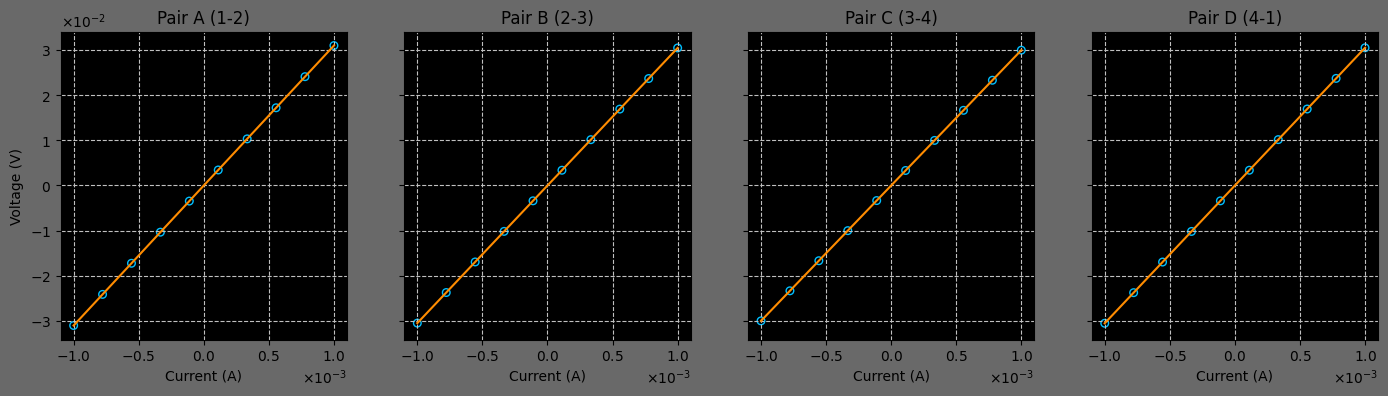

In [9]:
# Run optimised contact check
M91.ContactCheck.start()

#### Manual Contact Check

In [7]:
M91.ContactCheck.auto_optimise(False)
M91.ContactCheck.excitation_type("CURR")
M91.ContactCheck.excitation_current_start(-1E-3) 
M91.ContactCheck.excitation_current_end(1E-3)
M91.ContactCheck.number_of_points(15)
M91.ContactCheck.print_readable_snapshot(update=True)

M91_ContactCheck:
	parameter               value
--------------------------------------------------------------------------------
auto_optimise            :	False 
blanking_time            :	0.002 (s)
compliance_voltage       :	10 (V)
excitation_current_end   :	0.001 (A)
excitation_current_range :	AUTO (A)
excitation_current_start :	-0.001 (A)
excitation_type          :	CURR 
measure_voltage_range    :	AUTO (V)
minimum_r_squared        :	0.999 
number_of_points         :	15 
sampling_time            :	DEF (s)


Contact Check in progress ... Contact Check Complete.
Results:
		Gradient	Intercept	R-squared	Passed
Pair A (1-2):	11.592408	-0.000021	1.000000	True
Pair B (2-3):	11.602632	-0.000022	1.000000	True
Pair C (3-4):	11.620822	-0.000021	1.000000	True
Pair D (4-1):	11.610174	-0.000021	1.000000	True


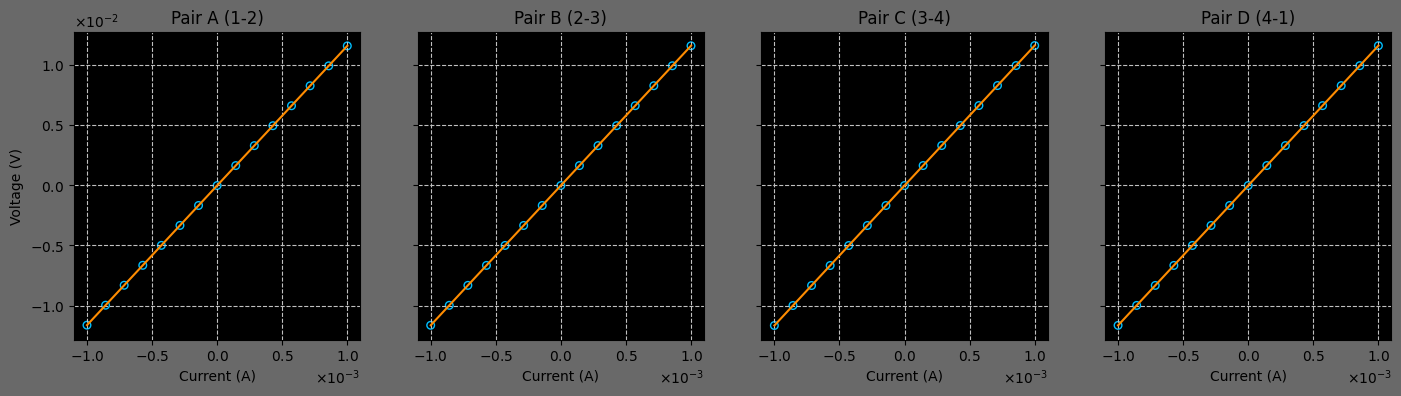

In [9]:
M91.ContactCheck.start()

#### Four-wire resistance measurement

In [10]:
M91.FourWire.excitation_plus_channel(1)
M91.FourWire.excitation_minus_channel(2)
M91.FourWire.measure_plus_channel(3)
M91.FourWire.measure_minus_channel(4)
M91.FourWire.excitation_reversal("ON")
M91.FourWire.excitation_current_value(1E-3)

M91.FourWire.print_readable_snapshot(update=True)

M91_FourWire:
	parameter                       value
--------------------------------------------------------------------------------
blanking_time                    :	0.002 (s)
compliance_voltage               :	10 (V)
excitation_current_range         :	AUTO (A)
excitation_current_value         :	0.001 (A)
excitation_measure_current_range :	AUTO (A)
excitation_minus_channel         :	2 
excitation_plus_channel          :	1 
excitation_reversal              :	ON 
excitation_type                  :	CURR 
maximum_samples                  :	100 
measure_minus_channel            :	4 
measure_plus_channel             :	3 
measure_voltage_range            :	AUTO (V)
minimum_SNR                      :	30 
sampling_time                    :	DEF (s)


In [11]:
M91.FourWire.start()

Four Wire measurement in progress ... Four Wire measurement complete.
-----------------------
Setup:
-----------------------
Contact Pair Excitation: namespace(Point1=1, Point2=2)
Contact Pair Sense: namespace(Point1=3, Point2=4)
Excitation Type: 1
Excitation Value: 0.001
Excitation Auto Range: True
Excitation Measurement Auto Range: True
Excitation Range: 0.001
Measurement Auto Range: True
Measurement Range: 0.001
Excitation Measurement Range: 0.01
Compliance Limit: 10.0
Blanking Time In Seconds: 0.002
Maximum Number Of Samples: 100
Minimum Resistance Snr: 30.0
Use Excitation Reversal: True
Sampling Time In Seconds: 0.016666666666666666
Guid: f3ed1553-c9ce-40a0-8ba5-9b0715e4849d
-----------------------
Results:
-----------------------
Resistance Snr: 409.86101590323335
Resistance Average In Ohms: 0.0049483069767618515
Resistance Standard Error In Ohms: 1.2073134025340259e-05
Voltage Average In Volts: 4.9469236e-06
Voltage Standard Error In Volts: 1.20696179187431e-08
Current Average I

namespace(Setup=namespace(ContactPairExcitation=namespace(Point1=1, Point2=2),
                          ContactPairSense=namespace(Point1=3, Point2=4),
                          ExcitationType=1,
                          ExcitationValue=0.001,
                          ExcitationAutoRange=True,
                          ExcitationMeasurementAutoRange=True,
                          ExcitationRange=0.001,
                          MeasurementAutoRange=True,
                          MeasurementRange=0.001,
                          ExcitationMeasurementRange=0.01,
                          ComplianceLimit=10.0,
                          BlankingTimeInSeconds=0.002,
                          MaximumNumberOfSamples=100,
                          MinimumResistanceSnr=30.0,
                          UseExcitationReversal=True,
                          SamplingTimeInSeconds=0.016666666666666666,
                          Guid='f3ed1553-c9ce-40a0-8ba5-9b0715e4849d'),
          ResistanceSn

Starting experimental run with id: 1. 
GUID: 5f37ee43-0000-0000-0000-019d85dcd31c


([<Axes: title={'center': 'Run #1, Experiment M91 example (some_sample)'}, xlabel='current (mA)', ylabel='voltage (μV)'>],
 [None])

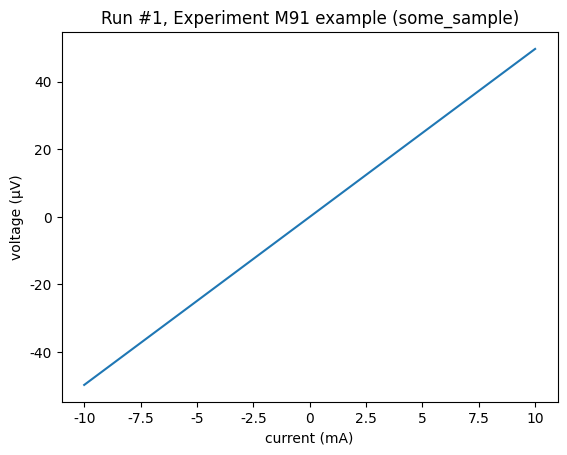

In [12]:
meas = Measurement()

current = Parameter('current',
                    label='current',
                    unit='A')

voltage = Parameter('voltage',
                         label='voltage',
                         unit='V')

meas.register_parameter(current)
meas.register_parameter(voltage, setpoints=[current])

with meas.run() as datasaver:
    meas_guid = datasaver.dataset.guid
    print(f'GUID: {meas_guid}')

    for x in np.linspace(-0.01, 0.01, 5):
        M91.FourWire.excitation_current_value(x)
            
        data = M91.FourWire.start(show_results=False, print_status=False) # print_status=False to turn off 'running' and 'complete' messages
        
        curr = data.Setup.ExcitationValue
        volt = data.VoltageAverageInVolts
        
                
        datasaver.add_result((current, curr),
                             (voltage, volt)
                            )
        time.sleep(2)
        
dataset = datasaver.dataset

plot_dataset(dataset)

#### Optimised Resistivity Measurement

In [13]:
M91.Resistivity.auto_optimise(True)
M91.Resistivity.print_readable_snapshot(update=True)

M91_Resistivity:
	parameter       value
--------------------------------------------------------------------------------
auto_optimise    :	True 
maximum_samples  :	100 
measure_range    :	AUTO (A or V)
minimum_SNR      :	30 
sample_thickness :	DEF (m)


In [16]:
data = M91.Resistivity.start(show_results=False) # show_results=False to hide display of results
        
current = data.Setup.ExcitationValue
resistivity = data.SheetResistivityAverageInOhmsPerSquare

print(f'Excitation current = {current} A, Sheet Resistivity = {resistivity} Ohms/Sq')

Resistivity measurement in progress ... Resistivity measurement complete.
Excitation current = 0.001 A, Sheet Resistivity = -0.021802791731891126 Ohms/Sq


In [7]:
# get the results again
data = M91.Resistivity.get_results()
# or get all the results
complete_data = M91.Resistivity.get_all_results()

In [8]:
# e.g. the first sample
complete_data.ResistivitySamples[0]

namespace(ResistivityInOhmMeters='NaN',
          SheetResistivityInOhmsPerSquare=-4.715214812474387,
          GeometryAResistivityInOhmMeters='NaN',
          GeometryASheetResistivityInOhmsPerSquare=-4.715218211743172,
          GeometryAFValue=0.9999999999987191,
          GeometryBResistivityInOhmMeters='NaN',
          GeometryBSheetResistivityInOhmsPerSquare=-4.715211413205602,
          GeometryBFValue=0.9999999999992795,
          Measurements=[namespace(ContactConfiguration='R2134',
                                  PositiveExcitation=namespace(VoltageInVolts=-0.1038745,
                                                               CurrentInAmps=0.0998228,
                                                               InCompliance=False,
                                                               VoltageOverload=False,
                                                               CurrentOverload=False),
                                  NegativeExcitation=namespace(Volta

#### Manual Resistivity Measurement

In [9]:
M91.sample_type("van_der_Pauw")

In [11]:
M91.Resistivity.auto_optimise(False)
M91.Resistivity.excitation_current_value(1E-3)
M91.Resistivity.minimum_SNR(1.1)
M91.Resistivity.print_readable_snapshot(update=True)

M91_Resistivity:
	parameter                       value
--------------------------------------------------------------------------------
auto_optimise                    :	False 
blanking_time                    :	0.002 (s)
compliance_voltage               :	10 (V)
excitation_current_range         :	AUTO (A)
excitation_current_value         :	0.001 (A)
excitation_measure_current_range :	AUTO (A)
excitation_type                  :	CURR 
maximum_samples                  :	100 
measure_voltage_range            :	AUTO (V)
minimum_SNR                      :	1.1 
sample_thickness                 :	DEF (m)
sampling_time                    :	DEF (s)


In [12]:
data = M91.Resistivity.start(show_results=False)

current = data.Setup.ExcitationValue
resistivity = data.SheetResistivityAverageInOhmsPerSquare

print(f'Excitation current = {current} A, Sheet Resistivity = {resistivity} Ohms/Sq')

Resistivity measurement in progress ... Resistivity measurement complete.
Excitation current = 0.001 A, Sheet Resistivity = -4.706111552043966 Ohms/Sq


In [13]:
# If you were to encounter an error
M91.read_error_queue()

'0,"No error"\r'

#### Optimised FastHall<sup>TM</sup> Measurement

In [3]:
M91.FastHall.user_defined_field(2.5)
M91.FastHall.auto_optimise(False)
M91.FastHall.excitation_current_value(1e-3)
M91.FastHall.print_readable_snapshot(update=True)

M91_FastHall:
	parameter                       value
--------------------------------------------------------------------------------
auto_optimise                    :	False 
averaging_samples                :	DEF 
blanking_time                    :	0.002 (s)
compliance_voltage               :	10 (V)
excitation_current_range         :	AUTO (A)
excitation_current_value         :	0.001 (A)
excitation_measure_current_range :	AUTO (A)
excitation_type                  :	CURR 
maximum_samples                  :	100 
measure_voltage_range            :	AUTO (V)
minimum_SNR                      :	30 
resistivity                      :	DEF (Ω.m or Ω/□)
sample_thickness                 :	DEF (m)
sampling_time                    :	DEF (s)
user_defined_field               :	2.5 (T)


In [5]:
data = M91.FastHall.start(print_statements=False)

current = data.Setup.ExcitationValue
hall_voltage = data.HallVoltageAverageInVolts

print(f'Excitation current = {current} A, Hall Voltage = {hall_voltage} V')

-----------------------
Setup:
-----------------------
Excitation Type: 1
Excitation Value: 0.001
Excitation Auto Range: True
Excitation Range: 0.001
Excitation Measurement Range: 0.01
Excitation Measurement Auto Range: True
Measurement Auto Range: True
Measurement Range: 0.001
Compliance Limit: 10.0
Minimum Hall Voltage Snr: 30.0
Max Number Of Samples: 100
User Defined Field Reading In Tesla: 2.5
Resistivity: NaN
Blanking Time In Seconds: 0.002
Number Of Voltage Compensation Samples To Average: 60
Sample Thickness In Meters: None
Sampling Time In Seconds: 0.016666666666666666
Guid: 10c90834-2117-41fa-a9a1-3d7e60f5fca2
-----------------------
Results:
-----------------------
Hall Voltage Snr: 0.017921933713315782
Hall Voltage Average In Volts: 7.10525000000169e-11
Hall Voltage Standard Error In Volts: 3.9645554512471915e-09
Hall Coefficient Average In Meters Cubed Per Coulomb: NaN
Hall Coefficient Standard Error In Meters Cubed Per Coulomb: NaN
Sheet Hall Coefficient Average In Meters 

## Hall Bar Sample

#### Contact Check

In [3]:
# change sample type to Hall
M91.sample_type("Hall_bar")
M91.ContactCheck.excitation_current_start(-100e-6)
M91.ContactCheck.excitation_current_end(100e-6)
M91.ContactCheck.number_of_points(21)
M91.ContactCheck.print_readable_snapshot(update=True)

M91_ContactCheck:
	parameter               value
--------------------------------------------------------------------------------
blanking_time            :	0.002 (s)
compliance_voltage       :	10 (V)
excitation_current_end   :	0.0001 (A)
excitation_current_range :	AUTO (A)
excitation_current_start :	-0.0001 (A)
excitation_type          :	CURR 
measure_voltage_range    :	AUTO (V)
minimum_r_squared        :	0.999 
number_of_points         :	21 
sampling_time            :	DEF (s)


In [ ]:
M91.ContactCheck.start()

#### DC Hall Measurement

In [18]:
M91.DCHall.user_defined_field(0)
M91.DCHall.excitation_current_value(0.01)
M91.DCHall.field_reversal('ON')
M91.DCHall.print_readable_snapshot(update=True)

M91_DCHall:
	parameter                       value
--------------------------------------------------------------------------------
blanking_time                    :	0.002 (s)
compliance_voltage               :	10 (V)
excitation_current_range         :	AUTO (A)
excitation_current_value         :	0.01 (A)
excitation_measure_current_range :	AUTO (A)
excitation_type                  :	CURR 
field_reversal                   :	ON 
maximum_samples                  :	100 
measure_voltage_range            :	AUTO (V)
minimum_SNR                      :	30 
resistivity                      :	DEF (Ω.m or Ω/□)
sample_thickness                 :	DEF (m)
sampling_time                    :	DEF (s)
user_defined_field               :	0 (T)


In [19]:
data_1 = M91.DCHall.start()

current = data_1.Setup.ExcitationValue
hall_voltage = data_1.HallVoltageAverageInVolts

print(f'Excitation current = {current} A, Hall Voltage = {hall_voltage} V')

DC Hall measurement in progress ... DC Hall measurement complete.
DC Hall measurement is in the waiting state. Reverse the field and then `continue_dc_hall`.
-----------------------
Setup:
-----------------------
Excitation Type: 1
Excitation Value: 0.01
Excitation Auto Range: True
Excitation Range: 0.01
Excitation Measurement Auto Range: True
Excitation Measurement Range: 0.01
Measurement Auto Range: True
Measurement Range: 0.001
Compliance Limit: 10.0
Maximum Number Of Samples: 100
User Defined Field Reading In Tesla: 0.0
With Field Reversal: True
Resistivity: NaN
Blanking Time In Seconds: 0.002
Sample Thickness In Meters: None
Minimum Snr: 30.0
Sampling Time In Seconds: 0.01667
Guid: 4d8c4287-1529-459f-b422-9f05b4034c40
-----------------------
Results:
-----------------------
Sample Type: 0
Dc Hall Snr: 94.51018257194387
Hall Voltage Average In Volts: 7.64764525e-07
Hall Voltage Standard Error In Volts: 8.091874379967886e-09
Hall Coefficient Average In Meters Cubed Per Coulomb: NaN


In [20]:
# After rotating your field direction
data_2 = M91.DCHall.continue_dc_hall()

current = data_2.Setup.ExcitationValue
hall_voltage = data_2.HallVoltageAverageInVolts

print(f'Excitation current = {current} A, Hall Voltage = {hall_voltage} V')

DC Hall measurement in progress ... DC Hall measurement complete.
-----------------------
Setup:
-----------------------
Excitation Type: 1
Excitation Value: 0.01
Excitation Auto Range: True
Excitation Range: 0.01
Excitation Measurement Auto Range: True
Excitation Measurement Range: 0.01
Measurement Auto Range: True
Measurement Range: 0.001
Compliance Limit: 10.0
Maximum Number Of Samples: 100
User Defined Field Reading In Tesla: 0.0
With Field Reversal: True
Resistivity: NaN
Blanking Time In Seconds: 0.002
Sample Thickness In Meters: None
Minimum Snr: 30.0
Sampling Time In Seconds: 0.01667
Guid: 4d8c4287-1529-459f-b422-9f05b4034c40
-----------------------
Results:
-----------------------
Sample Type: 0
Dc Hall Snr: 0.3841400790146754
Hall Voltage Average In Volts: 2.928466467826187e-09
Hall Voltage Standard Error In Volts: 7.623433814398497e-09
Hall Coefficient Average In Meters Cubed Per Coulomb: NaN
Hall Coefficient Standard Error In Meters Cubed Per Coulomb: NaN
Sheet Hall Coeffici

In [ ]:
M91.close()